In [ ]:
import pandas as pd

# Load Excel file
df_rtu = pd.read_csv('/content/RTU_CLEAN_faultandnofault.csv')
print(df_rtu.columns)
print(df_rtu[['Timestamp', 'Fault Detection Ground Truth']].head())


Index(['Timestamp', 'RTU: Supply Air Temperature',
       'RTU: Return Air Temperature', 'RTU: Supply Air Fan Status',
       'RTU: Circuit 1 Discharge Temperature',
       'RTU: Circuit 1 Condenser Outlet Temperature',
       'RTU: Circuit 1 Suction Temperature',
       'RTU: Circuit 2 Discharge Temperature',
       'RTU: Circuit 2 Condenser Outlet Temperature',
       'RTU: Circuit 2 Suction Temperature',
       'RTU: Circuit 1 Discharge Pressure',
       'RTU: Circuit 1 Condenser Outlet Pressure',
       'RTU: Circuit 1 Suction Pressure', 'RTU: Circuit 2 Discharge Pressure',
       'RTU: Circuit 2 Condenser Outlet Pressure',
       'RTU: Circuit 2 Suction Pressure',
       'RTU: Supply Air Volumetric Flow Rate', 'RTU: Electricity',
       'RTU: Natural Gas', 'Occupancy Mode Indicator',
       'Terminal: Room 102 Air Humidity', 'Terminal: Room 103 Air Humidity',
       'Terminal: Room 104 Air Humidity', 'Terminal: Room 105 Air Humidity',
       'Terminal: Room 106 Air Humidity', 'Ter

Epoch 1/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - loss: 7.7891 - pred_Room_102_Air_Temperature_loss: 0.6269 - pred_Room_103_Air_Temperature_loss: 0.5863 - pred_Room_104_Air_Temperature_loss: 0.4179 - pred_Room_105_Air_Temperature_loss: 0.5655 - pred_Room_106_Air_Temperature_loss: 0.5012 - pred_Room_202_Air_Temperature_loss: 0.5181 - pred_Room_203_Air_Temperature_loss: 0.6241 - pred_Room_204_Air_Temperature_loss: 0.5984 - pred_Room_205_Air_Temperature_loss: 0.5650 - pred_Room_206_Air_Temperature_loss: 0.5608 - pred_Room_Air_Temperature_Cooling_Setpoint_loss: 0.3521 - pred_Room_Air_Temperature_Heating_Setpoint_loss: 0.3847 - recon_Room_102_Air_Temperature_loss: 0.8502 - recon_Room_103_Air_Temperature_loss: 0.8231 - recon_Room_104_Air_Temperature_loss: 0.8157 - recon_Room_105_Air_Temperature_loss: 0.8700 - recon_Room_106_Air_Temperature_loss: 0.8482 - recon_Room_202_Air_Temperature_loss: 0.7974 - recon_Room_203_Air_Temperature_loss: 0.8379 - recon_Room_204_Air_Temperature_loss: 0.85

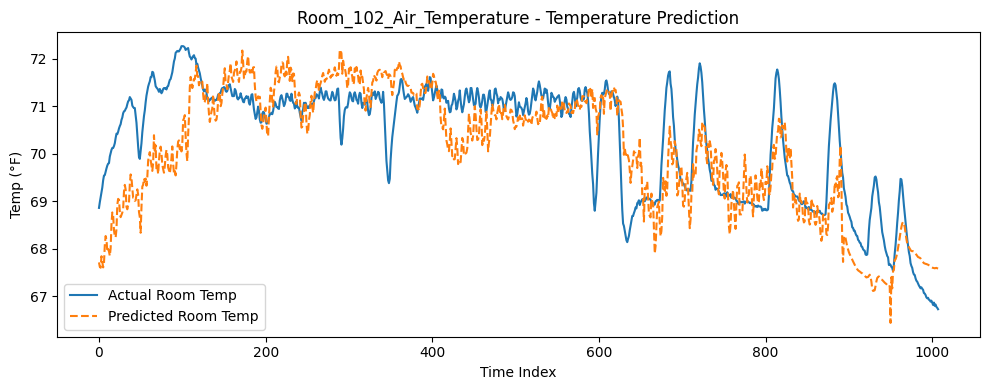

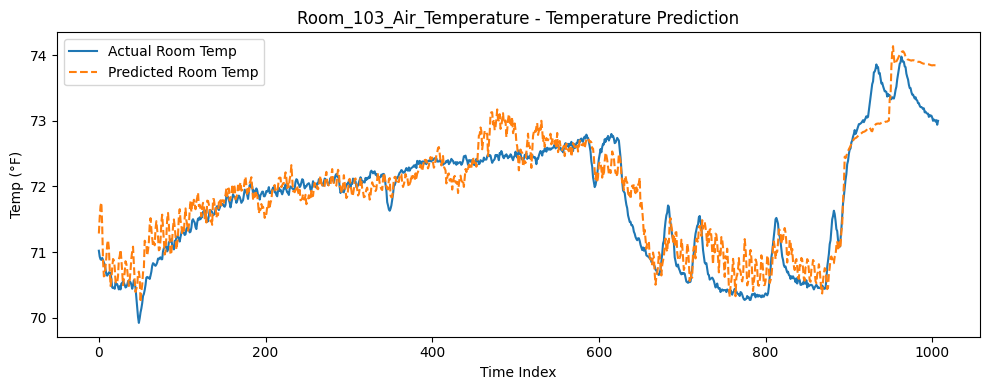

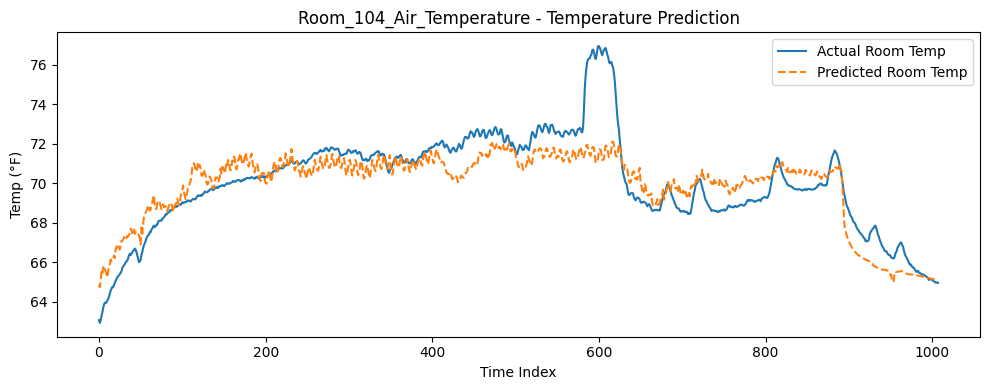

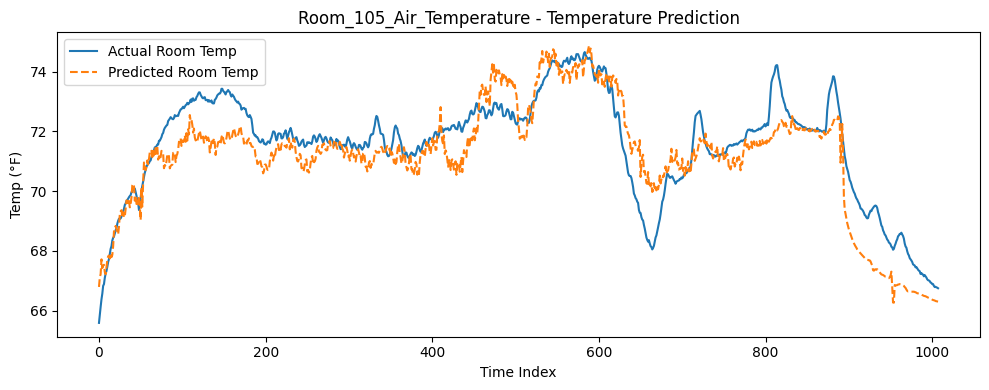

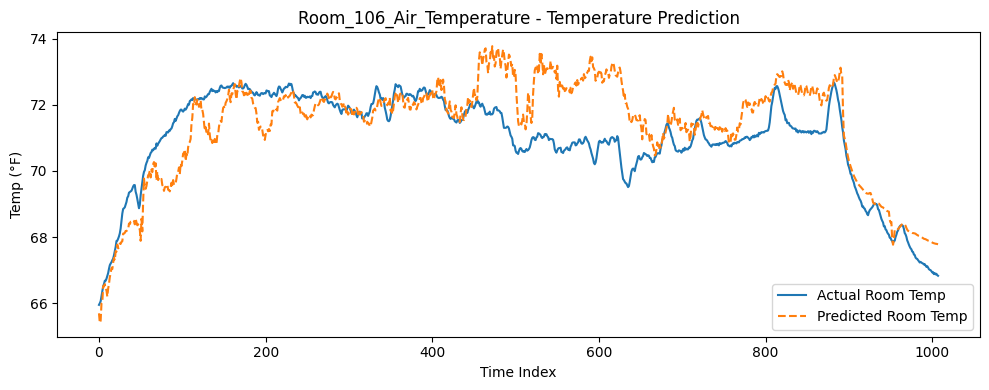

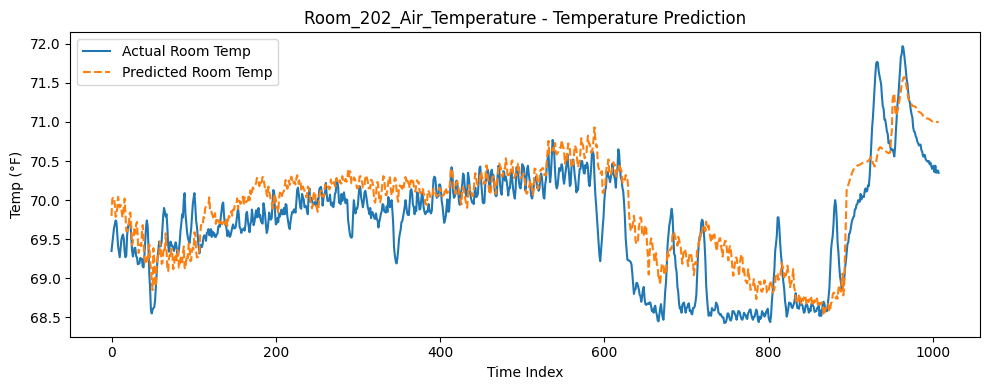

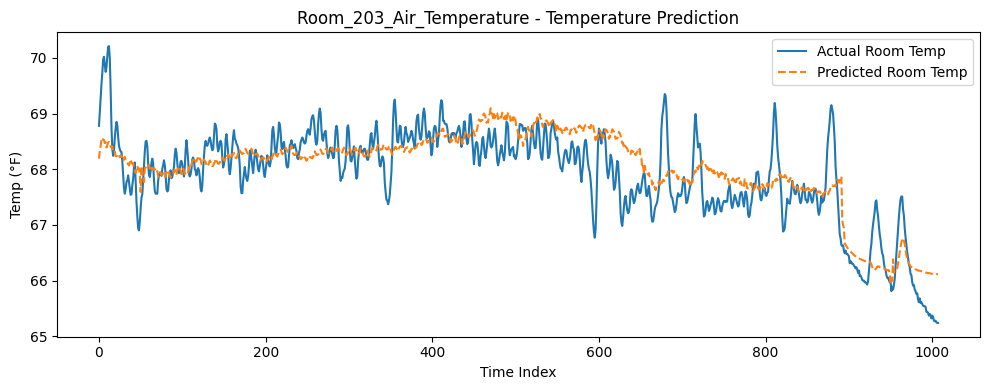

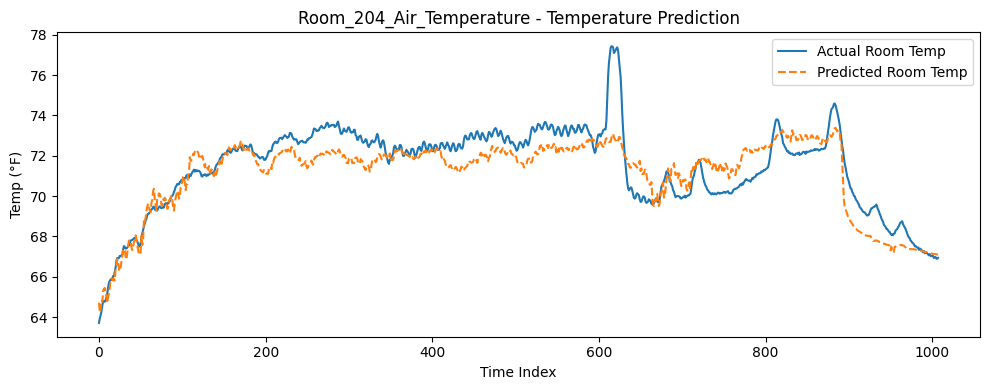

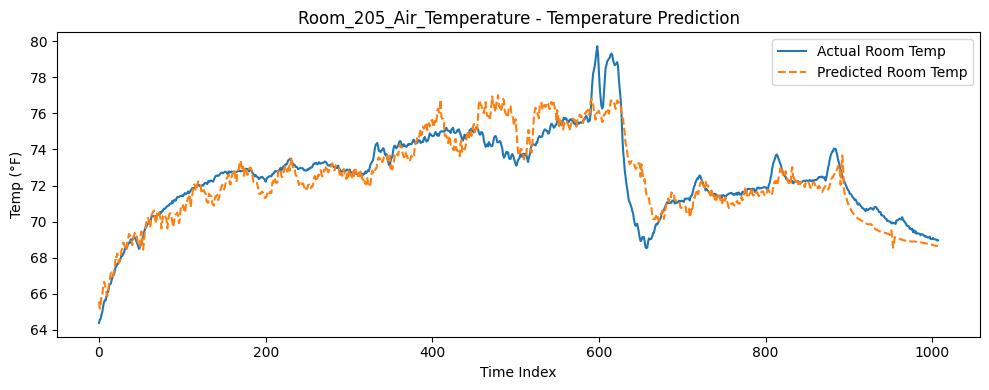

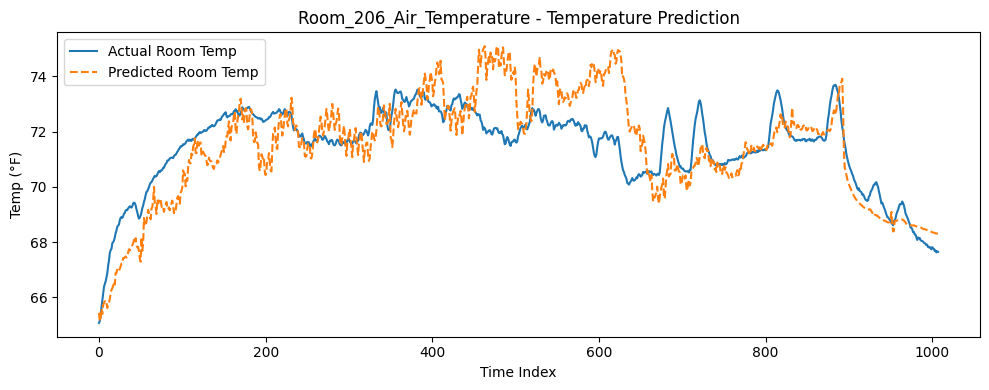

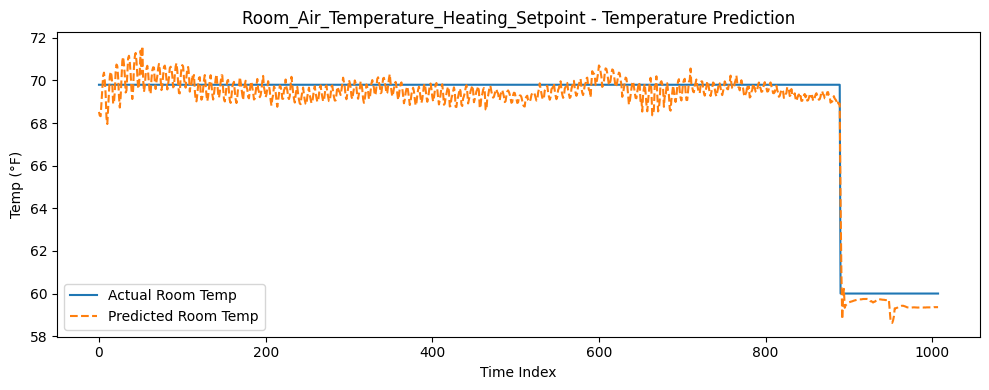

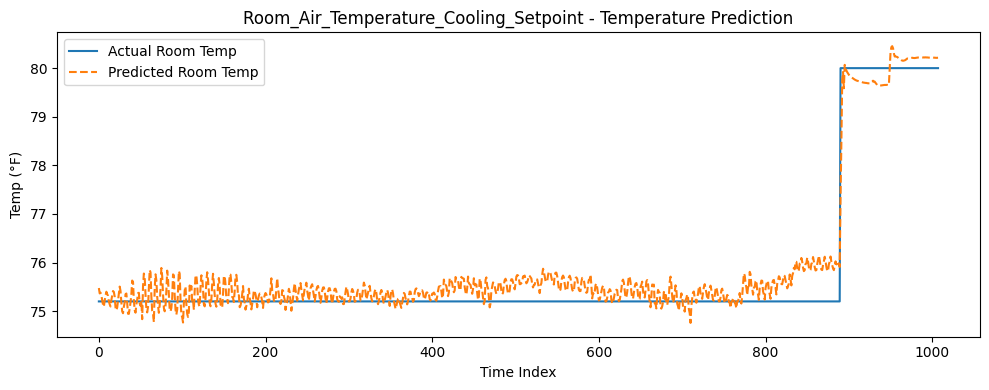

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# === LOAD DATA ===
df = pd.read_csv('RTU_CLEAN_faultandnofault.csv')
df.columns = df.columns.str.strip()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.sort_values('Timestamp')

# === FILTER NON-FAULTY DATA ===
df = df[df['Fault Detection Ground Truth'] == 0].reset_index(drop=True)

# === TIME-BASED ENCODING ===
hour_ohe = pd.get_dummies(df['Timestamp'].dt.hour, prefix='Hour')
dow_ohe = pd.get_dummies(df['Timestamp'].dt.dayofweek, prefix='DOW')
df = pd.concat([df, hour_ohe, dow_ohe], axis=1)

# === ENCODER INPUT FEATURES ===
exclude_cols = ['Fault Detection Ground Truth'] + [col for col in df.columns if 'Air Temperature' in col]
input_cols = [col for col in df.columns if col not in exclude_cols and col != 'Timestamp']

# === TARGETS: Room Temperatures ===
room_temp_cols = [col for col in df.columns if 'Terminal: Room' in col and 'Air Temperature' in col]

# === HANDLE MISSING INPUT VALUES ===
df[input_cols] = df[input_cols].replace(np.nan, -999)

# === SCALING ===
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(df[input_cols])

Y_scalers = {}
Y_scaled_dict = {}
for col in room_temp_cols:
    scaler = StandardScaler()
    Y_scaled_dict[col] = scaler.fit_transform(df[[col]])
    Y_scalers[col] = scaler

# === CREATE SEQUENCES ===
def create_sequences(X, Y_dict, seq_len=8):
    X_seq, Y_seq = [], {k: [] for k in Y_dict}
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        for k in Y_dict:
            Y_seq[k].append(Y_dict[k][i:i+seq_len])
    X_seq = np.array(X_seq)
    for k in Y_seq:
        Y_seq[k] = np.expand_dims(np.array(Y_seq[k]), -1)
    return X_seq, Y_seq

SEQ_LEN = 8
X_seq, Y_seq_dict = create_sequences(X_scaled, Y_scaled_dict, seq_len=SEQ_LEN)

# === TRAIN-TEST SPLIT ===
split = int(0.9 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
Y_train = {k: v[:split] for k, v in Y_seq_dict.items()}
Y_test  = {k: v[split:] for k, v in Y_seq_dict.items()}

# === BUILD SHARED ENCODER MULTI DECODER MODEL ===
num_features = X_seq.shape[2]
inp = Input(shape=(SEQ_LEN, num_features), name='encoder_input')
x = Conv1D(32, 3, activation='relu', padding='same')(inp)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
latent = MaxPooling1D(2, padding='same')(x)

outputs = []
clean_names = {}
for col in Y_train:
    clean_name = col.replace("Terminal: ", "").replace(" ", "_").replace(":", "")
    clean_names[clean_name] = col
    y = UpSampling1D(2)(latent)
    y = Conv1D(16, 3, activation='relu', padding='same')(y)
    y = UpSampling1D(2)(y)
    pred_out = Conv1D(1, 3, activation='linear', padding='same', name=f'pred_{clean_name}')(y)
    recon_out = Conv1D(num_features, 3, activation='linear', padding='same', name=f'recon_{clean_name}')(y)
    outputs.extend([pred_out, recon_out])

model = Model(inp, outputs)
model.compile(optimizer='adam',
              loss=['mse'] * len(outputs),
              loss_weights=[0.6, 0.4] * len(Y_train))

# === TRAINING ===
y_train_list, y_test_list = [], []
for clean_name, orig_col in clean_names.items():
    y_train_list.append(Y_train[orig_col])
    y_train_list.append(X_train)
    y_test_list.append(Y_test[orig_col])
    y_test_list.append(X_test)

model.fit(X_train, y_train_list,
          validation_data=(X_test, y_test_list),
          epochs=10, batch_size=32, verbose=1)

# === PREDICTIONS AND ROOM TEMP PLOTTING ===
preds = model.predict(X_test)

for i, (clean_name, orig_col) in enumerate(clean_names.items()):
    true_temp = Y_scalers[orig_col].inverse_transform(Y_test[orig_col][:, -1, 0].reshape(-1, 1)).flatten()
    pred_temp = Y_scalers[orig_col].inverse_transform(preds[2*i][:, -1, 0].reshape(-1, 1)).flatten()

    plt.figure(figsize=(10, 4))
    plt.plot(true_temp, label='Actual Room Temp')
    plt.plot(pred_temp, linestyle='--', label='Predicted Room Temp')
    plt.title(f'{clean_name} - Temperature Prediction')
    plt.xlabel('Time Index')
    plt.ylabel('Temp (°F)')
    plt.legend()
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-2-66624062.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_train_raw[col] = sc.fit_transform(Y_train_raw[[col]])
/tmp/ipython-input-2-66624062.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test_raw[col]  = sc.transform(Y_test_raw[[col]])
/tmp/ipython-input-2-66624062.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 8, 88)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 8, 32)     │      8,480 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 4, 32)     │          0 │ conv1d_12[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 4, 16)     │      1,552 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 2, 16)     │          0 │ conv1d_13[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_20    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_22    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_24    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_26    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_28    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_30    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_32    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_34    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_36    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_38    │ (None, 4, 16)     │          0 │ max_pooling1d_3[… │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 4, 16)     │        784 │ up_sampling1d_20… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 4, 16)     │        784 │ up_sampling1d_22… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 4, 16)     │        784 │ up_sampling1d_24… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 61,482 (240.16 KB)

 Trainable params: 61,482 (240.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - loss: 5.9304 - pred_Terminal_Room_102_Air_Temperature_loss: 0.5848 - pred_Terminal_Room_103_Air_Temperature_loss: 0.4647 - pred_Terminal_Room_104_Air_Temperature_loss: 0.3979 - pred_Terminal_Room_105_Air_Temperature_loss: 0.5361 - pred_Terminal_Room_106_Air_Temperature_loss: 0.4379 - pred_Terminal_Room_202_Air_Temperature_loss: 0.4766 - pred_Terminal_Room_203_Air_Temperature_loss: 0.5060 - pred_Terminal_Room_204_Air_Temperature_loss: 0.4426 - pred_Terminal_Room_205_Air_Temperature_loss: 0.5829 - pred_Terminal_Room_206_Air_Temperature_loss: 0.5078 - recon_Terminal_Room_102_Air_Temperature_loss: 0.7471 - recon_Terminal_Room_103_Air_Temperature_loss: 0.7339 - recon_Terminal_Room_104_Air_Temperature_loss: 0.7297 - recon_Terminal_Room_105_Air_Temperature_loss: 0.7417 - recon_Terminal_Room_106_Air_Temperature_loss: 0.7296 - recon_Terminal_Room_202_Air_Temperature_loss: 0.7201 - recon_Terminal_Room_203_Air_Temperature_loss: 0.7419 - reco

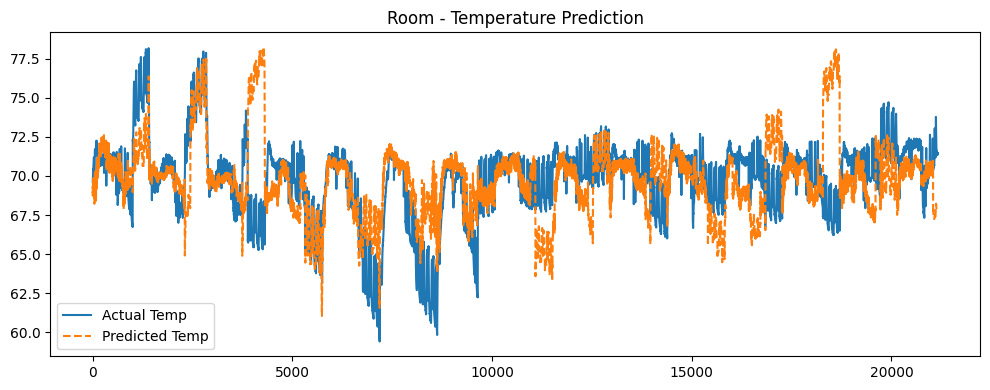

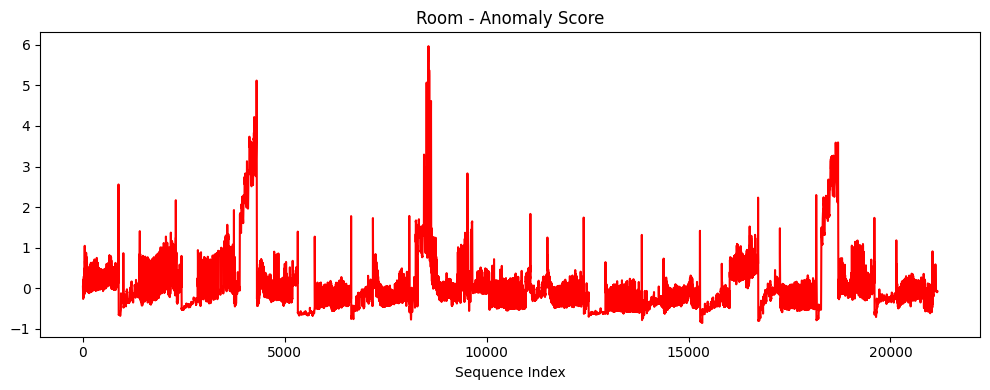

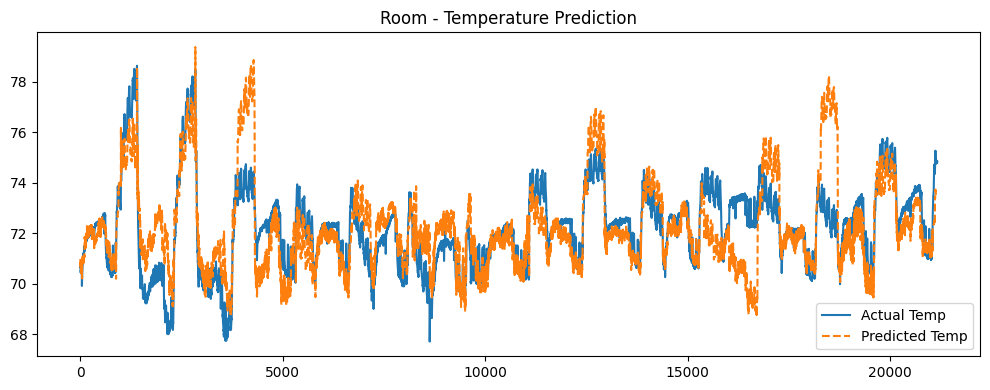

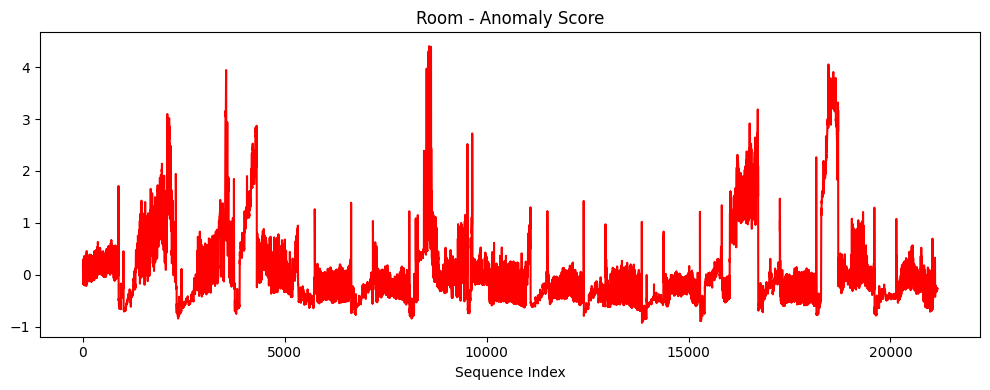

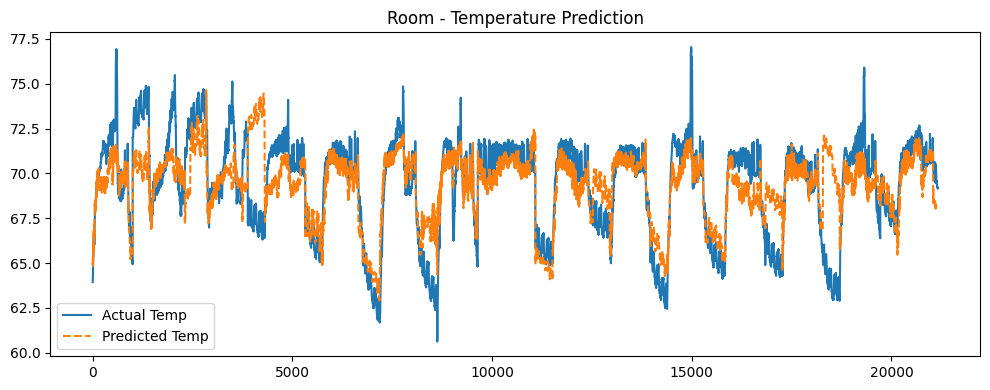

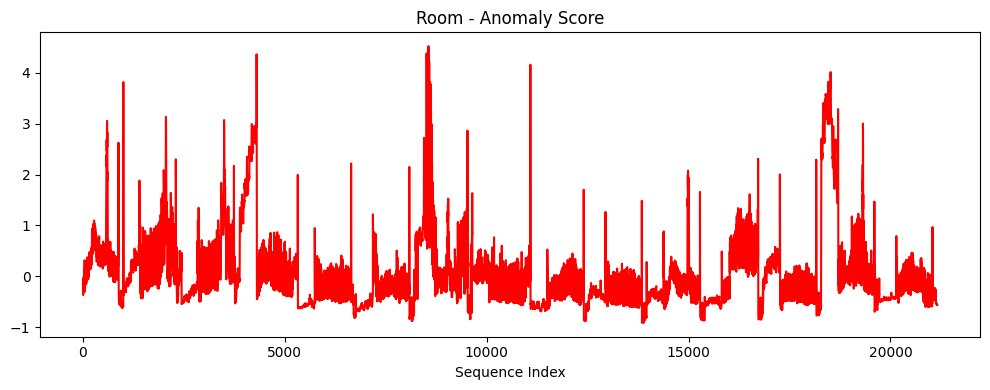

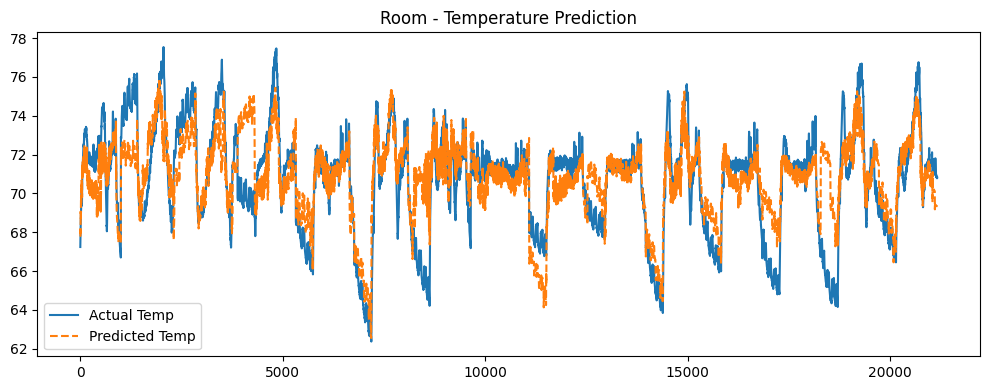

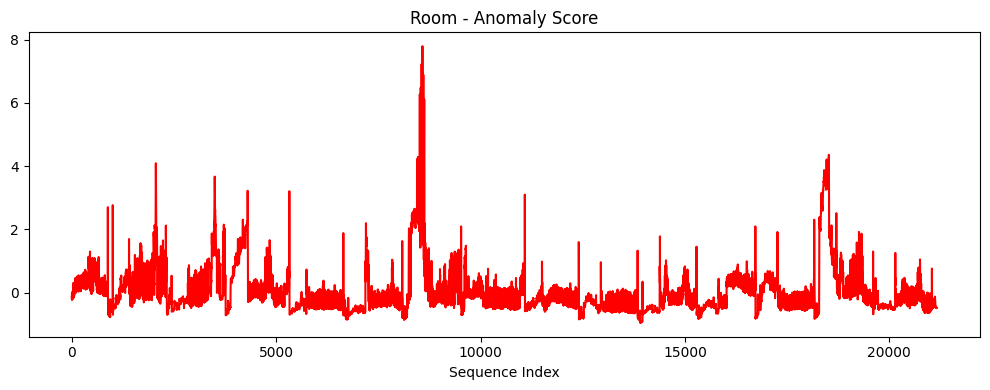

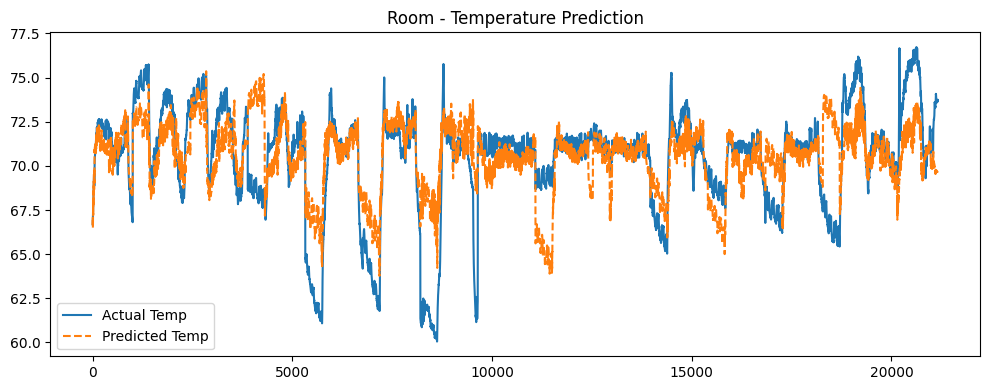

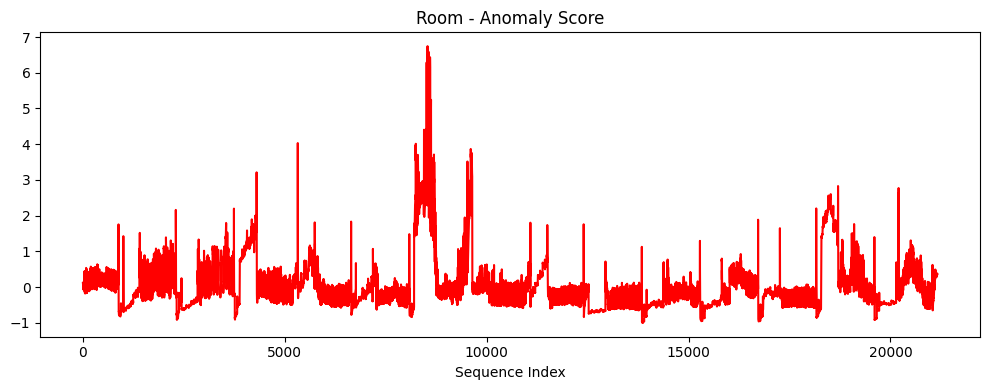

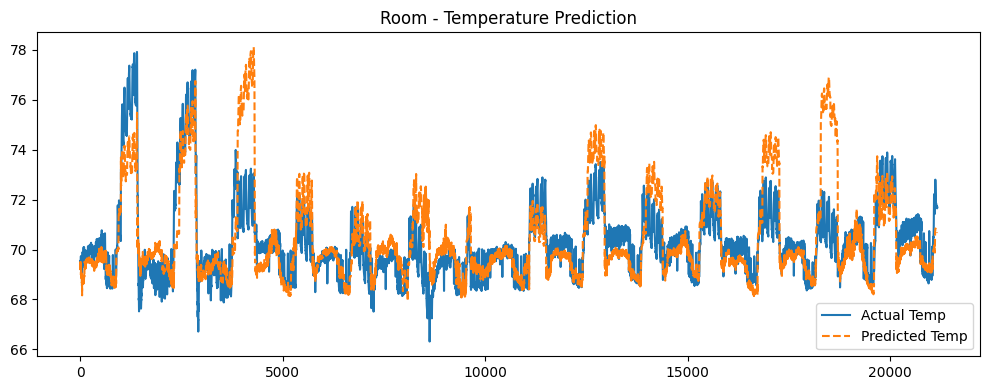

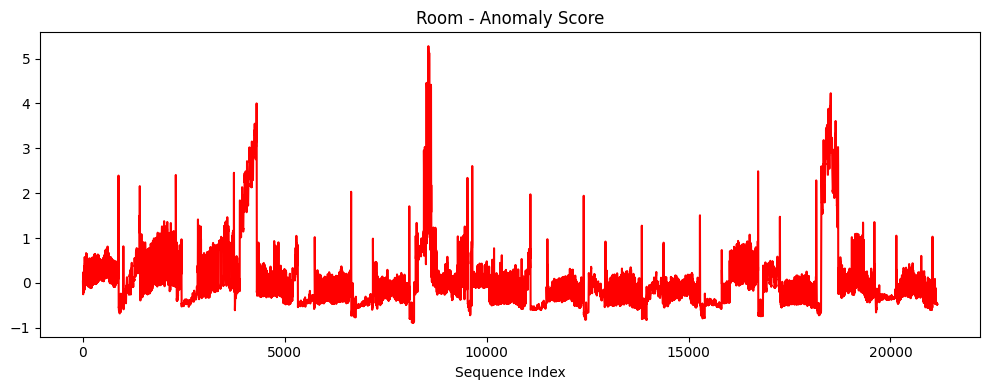

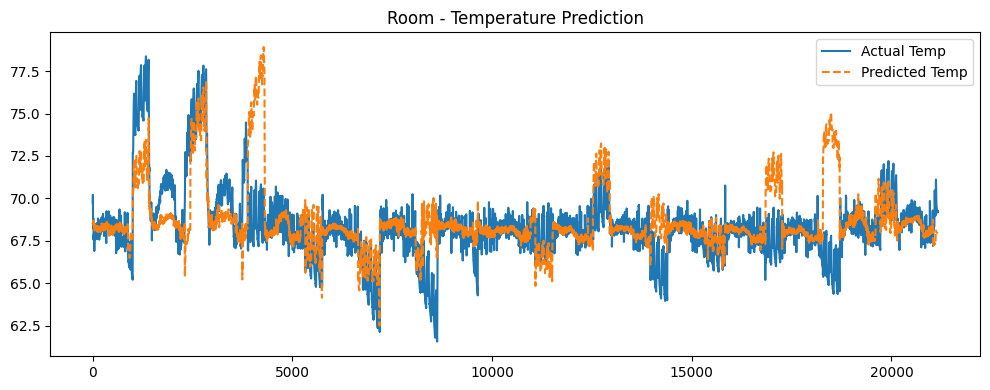

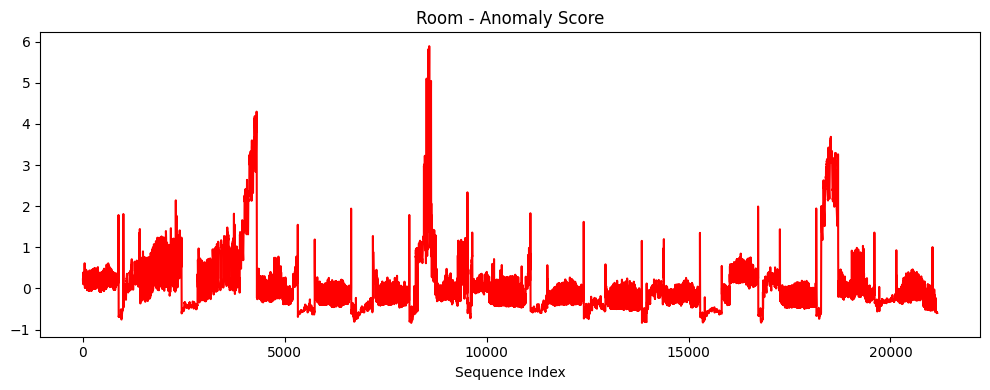

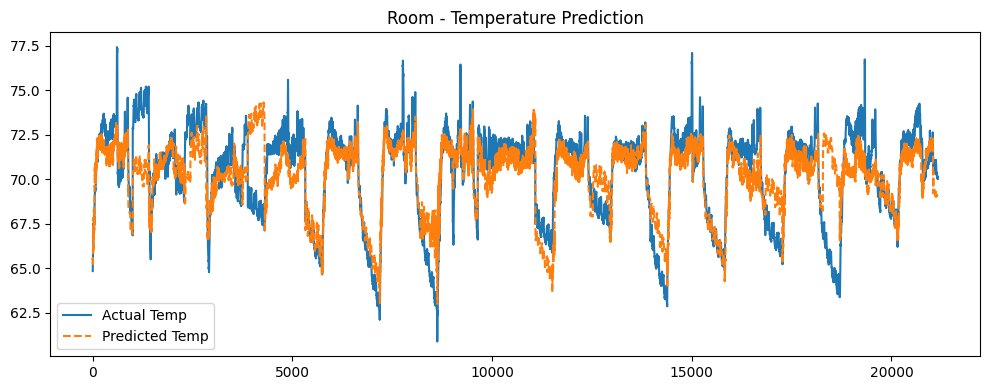

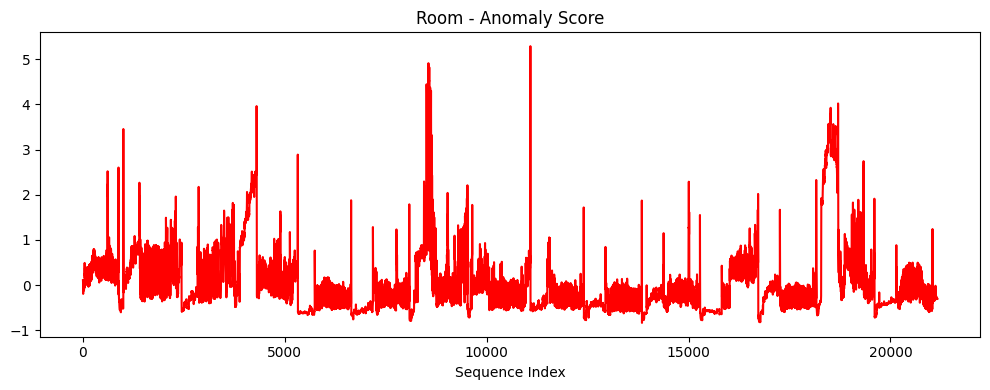

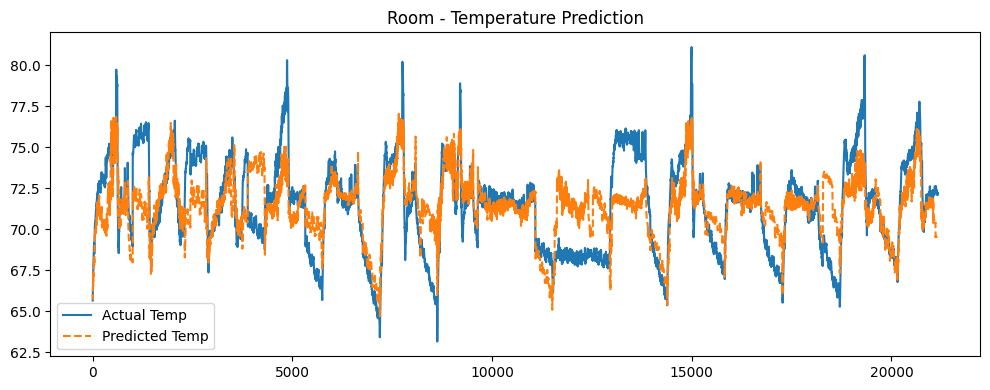

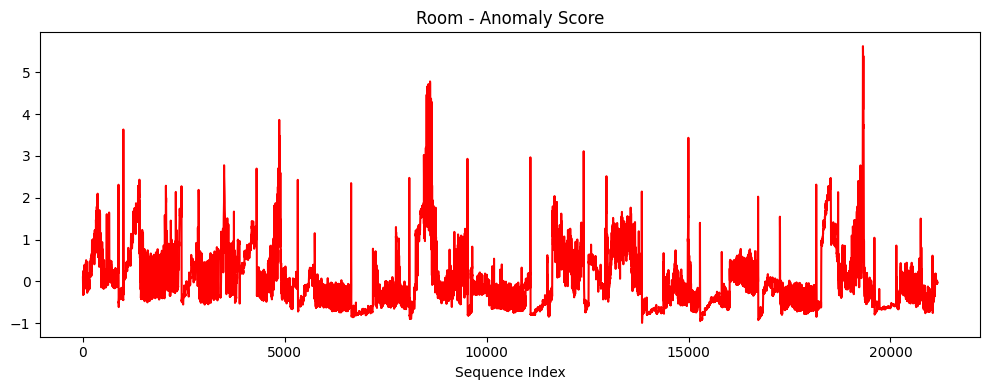

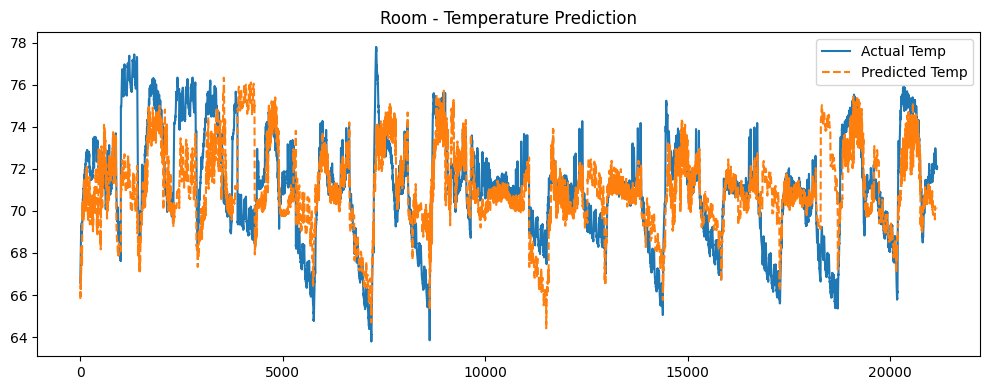

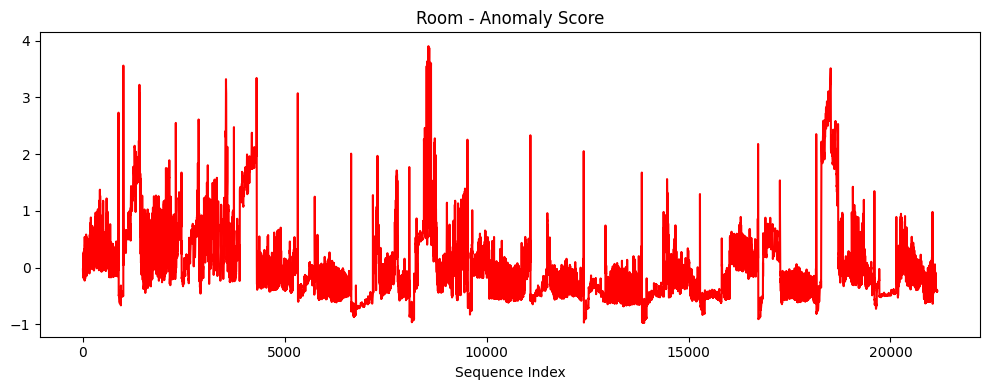

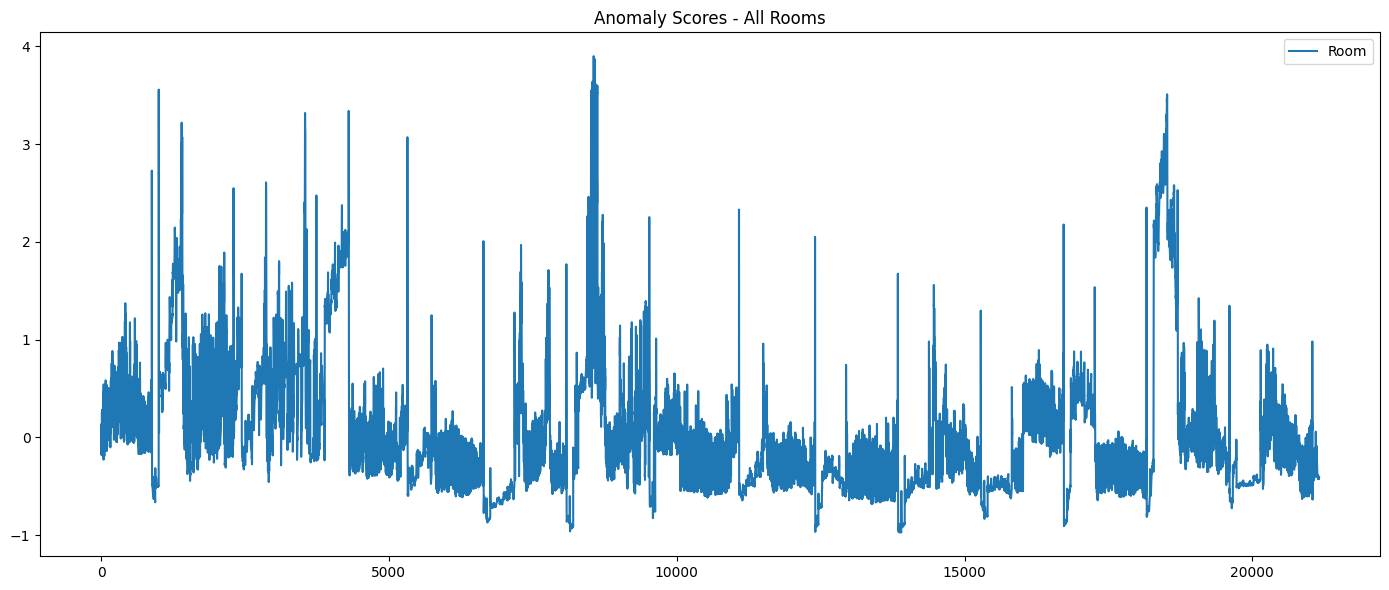

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
import tensorflow as tf

# === LOAD DATA ===
df = pd.read_csv('RTU_CLEAN_faultandnofault.csv')
df.columns = df.columns.str.strip()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.sort_values('Timestamp')

# === FEATURE ENGINEERING ===
hour_ohe = pd.get_dummies(df['Timestamp'].dt.hour, prefix='Hour')
dow_ohe = pd.get_dummies(df['Timestamp'].dt.dayofweek, prefix='DOW')
df = pd.concat([df, hour_ohe, dow_ohe], axis=1)

df.replace({np.nan: -999}, inplace=True)

# === DEFINE INPUT / TARGET ===
room_ids = [f"Room {i}" for i in [102, 103, 104, 105, 106, 202, 203, 204, 205, 206]]
target_cols = [f"Terminal: {r} Air Temperature" for r in room_ids]
clean_names = {c: c.replace(" ", "_").replace(":", "") for c in target_cols}

drop_cols = ['Timestamp', 'Fault Detection Ground Truth'] + target_cols
input_cols = [c for c in df.columns if c not in drop_cols]

X_raw = df[input_cols].values
Y_raw = df[target_cols].copy()
fault_label = df['Fault Detection Ground Truth'].values

# === SPLIT ===
normal_mask = fault_label == 0
normal_idx = np.where(normal_mask)[0]
split_point = int(0.9 * len(normal_idx))

train_idx = normal_idx[:split_point]
test_idx = np.concatenate([normal_idx[split_point:], np.where(fault_label == 1)[0]])

X_train_raw, Y_train_raw = X_raw[train_idx], Y_raw.iloc[train_idx]
X_test_raw,  Y_test_raw  = X_raw[test_idx],  Y_raw.iloc[test_idx]

# === SCALE ===
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train_raw)
X_test_scaled  = X_scaler.transform(X_test_raw)

Y_scalers = {}
for col in target_cols:
    sc = StandardScaler()
    Y_train_raw[col] = sc.fit_transform(Y_train_raw[[col]])
    Y_test_raw[col]  = sc.transform(Y_test_raw[[col]])
    Y_scalers[col] = sc

# === SEQUENCING ===
def create_sequences(X, Y_dict, idxs, seq_len=8):
    X_seq = []
    Y_seq_dict = {key: [] for key in Y_dict.columns}
    for i in range(len(idxs) - seq_len):
        idx_slice = idxs[i:i+seq_len]
        X_seq.append(X[idx_slice])
        for col in Y_dict.columns:
            Y_seq_dict[col].append(Y_dict[col].values[idx_slice])
    X_seq = np.array(X_seq)
    for col in Y_seq_dict:
        Y_seq_dict[col] = np.expand_dims(np.array(Y_seq_dict[col]), -1)
    return X_seq, Y_seq_dict

seq_len = 8
X_train_seq, Y_train_seq = create_sequences(X_train_scaled, Y_train_raw, np.arange(len(X_train_raw)), seq_len)
X_test_seq, Y_test_seq   = create_sequences(X_test_scaled,  Y_test_raw,  np.arange(len(X_test_raw)),  seq_len)

# === MODEL ===
input_dim = X_train_seq.shape[2]
inputs = Input(shape=(seq_len, input_dim), name='encoder_input')
x = Conv1D(32, 3, padding='same', activation='relu')(inputs)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, padding='same', activation='relu')(x)
encoded = MaxPooling1D(2, padding='same')(x)

outputs = []
for col in Y_train_seq:
    cname = clean_names[col]  # Clean layer name
    y = UpSampling1D(2)(encoded)
    y = Conv1D(16, 3, activation='relu', padding='same')(y)
    y = UpSampling1D(2)(y)
    pred_temp = Conv1D(1, 3, activation='linear', padding='same', name=f'pred_{cname}')(y)
    recon_in = Conv1D(input_dim, 3, activation='linear', padding='same', name=f'recon_{cname}')(y)
    outputs.extend([pred_temp, recon_in])

model = Model(inputs, outputs)
losses = ['mse'] * (2 * len(Y_train_seq))
weights = [0.6, 0.4] * len(Y_train_seq)
model.compile(optimizer='adam', loss=losses, loss_weights=weights)
model.summary()

# === FIT ===
y_train_list = []
for col in Y_train_seq:
    y_train_list.append(Y_train_seq[col])
    y_train_list.append(X_train_seq)
y_test_list = []
for col in Y_test_seq:
    y_test_list.append(Y_test_seq[col])
    y_test_list.append(X_test_seq)

model.fit(X_train_seq, y_train_list, validation_data=(X_test_seq, y_test_list),
          epochs=10, batch_size=32, verbose=1)

# === INFERENCE + SCORING ===
preds = model.predict(X_test_seq)
anomaly_scores = {}

for i, col in enumerate(Y_test_seq):
    room = col.split()[1]
    true = Y_test_seq[col][:, -1, 0]
    pred = preds[2*i][:, -1, 0]
    rat_mse = (true - pred)**2
    x_mse = np.mean((X_test_seq[:, -1, :] - preds[2*i+1][:, -1, :])**2, axis=1)

    rat_norm = (rat_mse - np.mean(rat_mse)) / (np.std(rat_mse) + 1e-8)
    x_norm = (x_mse - np.mean(x_mse)) / (np.std(x_mse) + 1e-8)
    score = 0.6 * rat_norm + 0.4 * x_norm
    anomaly_scores[room] = score

    # Plot predictions
    inv_true = Y_scalers[col].inverse_transform(true.reshape(-1, 1)).flatten()
    inv_pred = Y_scalers[col].inverse_transform(pred.reshape(-1, 1)).flatten()
    plt.figure(figsize=(10,4))
    plt.plot(inv_true, label='Actual Temp')
    plt.plot(inv_pred, '--', label='Predicted Temp')
    plt.title(f'{room} - Temperature Prediction')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot anomaly score
    plt.figure(figsize=(10,4))
    plt.plot(score, label='Anomaly Score', color='red')
    plt.title(f'{room} - Anomaly Score')
    plt.xlabel("Sequence Index")
    plt.tight_layout()
    plt.show()

# === COMBINED PLOT ===
plt.figure(figsize=(14, 6))
for room, score in anomaly_scores.items():
    plt.plot(score, label=room)
plt.legend()
plt.title("Anomaly Scores - All Rooms")
plt.tight_layout()
plt.show()


In [ ]:
!pip install tensorflow scikit-learn pandas matplotlib


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 88)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4, 32)          │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 10)          │           490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,306 (44.16 KB)

 Trainable params: 11,306 (44.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5773 - val_loss: 0.2701
Epoch 2/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0930 - val_loss: 0.2721
Epoch 3/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0626 - val_loss: 0.2747
Epoch 4/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0509 - val_loss: 0.2270
Epoch 5/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0417 - val_loss: 0.2335
Epoch 6/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0368 - val_loss: 0.2204
Epoch 7/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0340 - val_loss: 0.2405
Epoch 8/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0302 - val_loss: 0.2477
Epoch 9/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0292 - val_loss: 0.2566
Epoch 10/10
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0268 - val_loss: 0.2557
945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


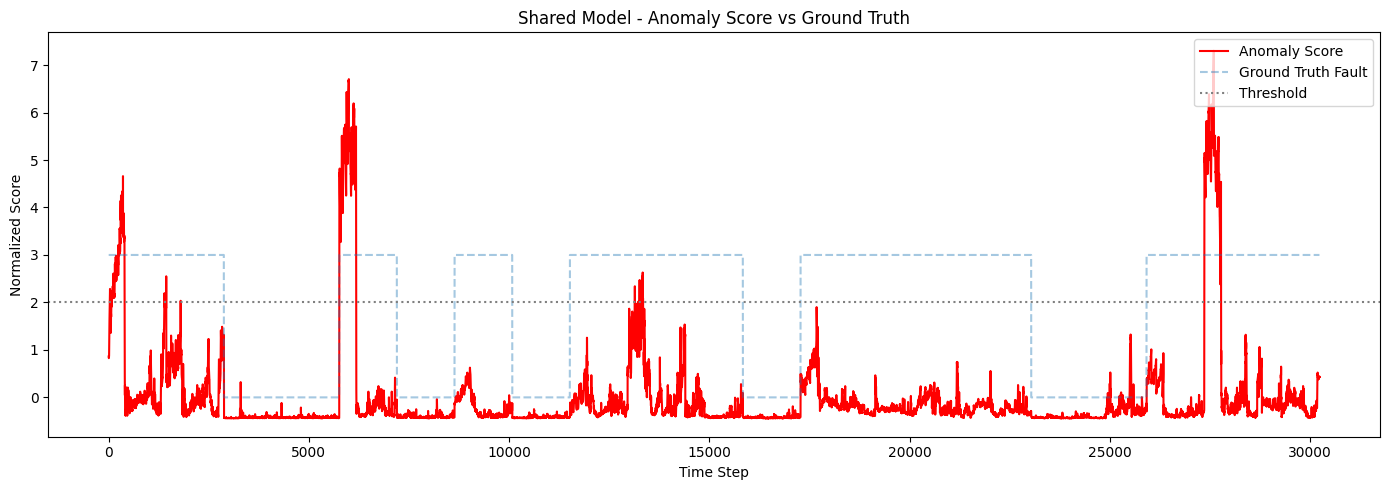

In [1]:
# === INSTALL AND IMPORTS ===
!pip install tensorflow scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
import matplotlib.pyplot as plt

# === LOAD AND CLEAN DATA ===
df = pd.read_csv('RTU_CLEAN_faultandnofault.csv')
df.columns = df.columns.str.strip()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.sort_values('Timestamp')

# Extract fault label
fault_label = df['Fault Detection Ground Truth'].values
df = df.drop(columns=['Fault Detection Ground Truth'])

# === ONE-HOT ENCODING ===
hour_ohe = pd.get_dummies(df['Timestamp'].dt.hour, prefix='Hour')
dow_ohe = pd.get_dummies(df['Timestamp'].dt.dayofweek, prefix='DOW')
df = pd.concat([df, hour_ohe, dow_ohe], axis=1)

# === HANDLE MISSING VALUES ===
df.replace({np.nan: -999}, inplace=True)

# === DEFINE FEATURES ===
target_rooms = [f'Terminal: Room {r} Air Temperature' for r in
                ['102','103','104','105','106','202','203','204','205','206']]
input_features = df.columns.difference(['Timestamp'] + target_rooms).tolist()

# === SPLIT DATA: Use only normal data for training ===
normal_mask = fault_label == 0
normal_df = df[normal_mask].reset_index(drop=True)

X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(normal_df[input_features])

Y_scaler = StandardScaler()
Y_scaled = Y_scaler.fit_transform(normal_df[target_rooms])

# === CREATE SEQUENCES ===
def create_sequences(X, Y, seq_len=8):
    X_seq, Y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len-1])  # predict next-step only
    return np.array(X_seq), np.array(Y_seq)

seq_len = 4
X_seq, Y_seq = create_sequences(X_scaled, Y_scaled, seq_len)
split_idx = int(0.9 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
Y_train, Y_test = Y_seq[:split_idx], Y_seq[split_idx:]

# === BUILD SHARED ENCODER-DECODER MODEL ===
input_dim = X_train.shape[2]
output_dim = Y_train.shape[1]

inp = Input(shape=(seq_len, input_dim))
x = Conv1D(32, 3, activation='relu', padding='same')(inp)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(output_dim, 3, activation='linear', padding='same')(x)

# Final prediction is last time step output
output = x[:, -1, :]  # shape: (batch, output_dim)

model = Model(inputs=inp, outputs=output)
model.compile(optimizer='adam', loss='mse')
model.summary()

# === TRAIN ===
model.fit(X_train, Y_train,
          validation_data=(X_test, Y_test),
          epochs=10, batch_size=32)

# === FULL DATA INFERENCE ===
full_X_scaled = X_scaler.transform(df[input_features])
full_Y_scaled = Y_scaler.transform(df[target_rooms])
X_full_seq, Y_full_seq = create_sequences(full_X_scaled, full_Y_scaled, seq_len)
fault_seq = fault_label[seq_len:]

preds = model.predict(X_full_seq)
mse = np.mean((Y_full_seq - preds)**2, axis=1)

# === NORMALIZE ANOMALY SCORES ===
anomaly_score = (mse - np.mean(mse)) / (np.std(mse) + 1e-8)

# === PLOT ANOMALY SCORES VS GROUND TRUTH ===
threshold = 2.0
plt.figure(figsize=(14, 5))
plt.plot(anomaly_score, label='Anomaly Score', color='red')
plt.plot((fault_seq > 0)*3, label='Ground Truth Fault', linestyle='--', alpha=0.4)
plt.axhline(threshold, color='gray', linestyle=':', label='Threshold')
plt.title("Shared Model - Anomaly Score vs Ground Truth")
plt.xlabel("Time Step")
plt.ylabel("Normalized Score")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("shared_model_anomaly_plot.png")
plt.show()


In [ ]:
# === IMPORTS AND SETUP ===
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import tensorflow as tf

# === LOAD AND PREPROCESS DATA ===
df = pd.read_csv('RTU_CLEAN_faultandnofault.csv')
df.columns = df.columns.str.strip()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.sort_values('Timestamp')

# Extract and drop ground truth
fault_label = df['Fault Detection Ground Truth'].values
df.drop(columns=['Fault Detection Ground Truth'], inplace=True)

# One-hot encode timestamp
hour_ohe = pd.get_dummies(df['Timestamp'].dt.hour, prefix='Hour')
dow_ohe = pd.get_dummies(df['Timestamp'].dt.dayofweek, prefix='DOW')
df = pd.concat([df, hour_ohe, dow_ohe], axis=1)

# Replace NaNs with -999
df.fillna(-999, inplace=True)

# === FEATURE SELECTION ===
room_cols = [f'Terminal: Room {r} Air Temperature' for r in
             ['102','103','104','105','106','202','203','204','205','206']]
exclude = ['Timestamp'] + room_cols
input_features = df.columns.difference(exclude).tolist()

# === TRAIN/TEST SPLIT BASED ON FAULT ===
normal_mask = fault_label == 0
df_normal = df[normal_mask].reset_index(drop=True)
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(df_normal[input_features])

Y_scalers = {}
Y_scaled_dict = {}
for col in room_cols:
    scaler = StandardScaler()
    Y_scaled = scaler.fit_transform(df_normal[[col]])
    Y_scalers[col] = scaler
    Y_scaled_dict[col] = Y_scaled

# === SEQUENCE CREATION ===
def create_sequences_multi(X, Y_dict, seq_len=8):
    X_seq, Y_seq = [], {z: [] for z in Y_dict}
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        for z, Y in Y_dict.items():
            Y_seq[z].append(Y[i:i+seq_len])
    X_seq = np.array(X_seq)
    for z in Y_seq:
        Y_seq[z] = np.expand_dims(np.array(Y_seq[z]), -1)
    return X_seq, Y_seq

seq_len = 8
X_seq, Y_seq_dict = create_sequences_multi(X_scaled, Y_scaled_dict, seq_len)
split_idx = int(0.9 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
Y_train = {z: Y_seq_dict[z][:split_idx] for z in Y_seq_dict}
Y_test  = {z: Y_seq_dict[z][split_idx:] for z in Y_seq_dict}

# === MODEL BUILDING ===
num_features = X_seq.shape[2]
inputs = Input(shape=(seq_len, num_features))
x = Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)

decoder_outputs = []
for col in Y_seq_dict:
    safe_name = col.replace(':','').replace(' ','_')
    y = UpSampling1D(2)(encoded)
    y = Conv1D(16, 3, activation='relu', padding='same')(y)
    y = UpSampling1D(2)(y)
    pred = Conv1D(1, 3, activation='linear', padding='same', name=f'pred_{safe_name}')(y)
    recon = Conv1D(num_features, 3, activation='linear', padding='same', name=f'recon_{safe_name}')(y)
    decoder_outputs.extend([pred, recon])

model = Model(inputs, decoder_outputs)
model.compile(optimizer='adam',
              loss=['mse'] * len(decoder_outputs),
              loss_weights=[0.6 if i % 2 == 0 else 0.4 for i in range(len(decoder_outputs))])

# === TRAINING ===
y_train_list, y_test_list = [], []
for tgt in Y_seq_dict:
    y_train_list.append(Y_train[tgt])
    y_train_list.append(X_train)
    y_test_list.append(Y_test[tgt])
    y_test_list.append(X_test)

model.fit(X_train, y_train_list, validation_data=(X_test, y_test_list), epochs=10, batch_size=64)

# === FULL INFERENCE FOR ANOMALY EVAL ===
X_all_scaled = X_scaler.transform(df[input_features])
Y_all_scaled = {col: Y_scalers[col].transform(df[[col]]) for col in room_cols}
X_seq_all, Y_seq_all = create_sequences_multi(X_all_scaled, Y_all_scaled, seq_len)
fault_seq = fault_label[seq_len:]

preds = model.predict(X_seq_all)

# === ANOMALY SCORE CALCULATION ===
anomaly_scores = {}
for i, col in enumerate(room_cols):
    safe_name = col.replace(':','').replace(' ','_')
    pred_temp = preds[2*i][:, -1, 0]
    true_temp = Y_seq_all[col][:, -1, 0]
    recon_input = preds[2*i+1][:, -1, :]
    true_input = X_seq_all[:, -1, :]

    pred_mse = (true_temp - pred_temp)**2
    recon_mask = (true_input != -999)
    recon_mse = np.sum(((true_input - recon_input)**2) * recon_mask, axis=1) / (np.sum(recon_mask, axis=1) + 1e-8)

    pred_norm = (pred_mse - pred_mse.mean()) / (pred_mse.std() + 1e-8)
    recon_norm = (recon_mse - recon_mse.mean()) / (recon_mse.std() + 1e-8)
    anomaly_score = 0.6 * pred_norm + 0.4 * recon_norm
    anomaly_scores[col] = anomaly_score

# === PLOTTING ===
for col, score in anomaly_scores.items():
    plt.figure(figsize=(12, 4))
    plt.plot(score, label='Anomaly Score', color='red')
    plt.plot((fault_seq > 0)*3, label='Ground Truth Fault', linestyle='--', alpha=0.5)
    plt.axhline(2.0, color='gray', linestyle=':', label='Threshold')
    plt.title(f'Room {col.split()[2]} - Anomaly Detection')
    plt.xlabel("Time Step")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


Epoch 1/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - loss: 7.7911 - pred_Terminal_Room_102_Air_Temperature_loss: 0.7205 - pred_Terminal_Room_103_Air_Temperature_loss: 0.6352 - pred_Terminal_Room_104_Air_Temperature_loss: 0.6293 - pred_Terminal_Room_105_Air_Temperature_loss: 0.9924 - pred_Terminal_Room_106_Air_Temperature_loss: 0.8848 - pred_Terminal_Room_202_Air_Temperature_loss: 0.6437 - pred_Terminal_Room_203_Air_Temperature_loss: 0.6470 - pred_Terminal_Room_204_Air_Temperature_loss: 0.6573 - pred_Terminal_Room_205_Air_Temperature_loss: 0.6926 - pred_Terminal_Room_206_Air_Temperature_loss: 0.7116 - recon_Terminal_Room_102_Air_Temperature_loss: 0.8523 - recon_Terminal_Room_103_Air_Temperature_loss: 0.8623 - recon_Terminal_Room_104_Air_Temperature_loss: 0.8741 - recon_Terminal_Room_105_Air_Temperature_loss: 0.8804 - recon_Terminal_Room_106_Air_Temperature_loss: 0.8566 - recon_Terminal_Room_202_Air_Temperature_loss: 0.8893 - recon_Terminal_Room_203_Air_Temperature_loss: 0.8501 - reco